# Curated 25-scenario active inverse-optimization benchmark

This notebook permanently records a compact one-factor-at-a-time benchmark of the **Uniform Random Query + Sequential Incenter** algorithm. It avoids the full 34,560-scenario Cartesian grid. A clean dimension-5 reference environment is changed along exactly one benchmark axis at a time, covering every dimension, expert regime, decision-space family, query geometry, observation-noise family, and parameter-noise family at least once.

Each scenario has a maximum horizon of 30. After each observed $Y_t$, the external benchmark rule evaluates the updated estimate on 100 hidden queries sampled uniformly from the unit sphere. It stops at the first time every hidden-query normalized regret is numerically zero; otherwise it continues to 30. The algorithm never receives $\theta^\star$, latent $X_t$, hidden queries, regret values, or the stopping calculation. Final angular error and normalized regret are reported separately, with no composite score. One common scenario seed is used in this first controlled pass.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from invoptlab.active import (
    ActiveBenchmarkSuite,
    ActiveEvaluationConfig,
    ActiveScenarioConfig,
    DecisionSpaceConfig,
    ExpertConfig,
    ObservationNoiseConfig,
    ParameterNoiseConfig,
    QuerySpaceConfig,
    RegretStoppingConfig,
    UniformRandomIncenterAlgorithm,
    evaluate_active_benchmark,
)

MAX_HORIZON = 30
SCENARIO_SEED = 0
QUERY_CANDIDATES = 32
HIDDEN_TEST_QUERIES = 100
EVALUATION_SEED = 501
ZERO_REGRET_TOLERANCE = 1e-8

settings = pd.DataFrame({
    'setting': ['scenario templates', 'seed per template', 'maximum horizon',
                'query candidates', 'hidden test queries', 'evaluation seed',
                'stopping rule'],
    'value': [25, SCENARIO_SEED, MAX_HORIZON, QUERY_CANDIDATES,
              HIDDEN_TEST_QUERIES, EVALUATION_SEED, 'first zero hidden-test regret'],
})
display(settings)

,setting,value
0,scenario templates,25
1,seed per template,0
2,maximum horizon,30
3,query candidates,32
4,hidden test queries,100
5,evaluation seed,501
6,stopping rule,first zero hidden-test regret


In [2]:
def make_scenario(
    name, category, *, dimension=5, expert=None, decision=None, query=None,
    observation=None, parameter=None,
):
    return ActiveScenarioConfig(
        name=name,
        dimension=dimension,
        horizon=MAX_HORIZON,
        seed=SCENARIO_SEED,
        expert=expert or ExpertConfig(kind='min'),
        decision_space=decision or DecisionSpaceConfig(kind='independent_binary'),
        query_space=query or QuerySpaceConfig(kind='dense', candidate_count=QUERY_CANDIDATES),
        observation_noise=observation or ObservationNoiseConfig(kind='clean'),
        parameter_noise=parameter or ParameterNoiseConfig(kind='none'),
        metadata={'category': category},
    )

def q(kind, **kwargs):
    return QuerySpaceConfig(kind=kind, candidate_count=QUERY_CANDIDATES, **kwargs)

scenarios = [
    make_scenario('reference', 'Reference'),
    make_scenario('dimension-20', 'Dimension', dimension=20),
    make_scenario('dimension-50', 'Dimension', dimension=50),
    make_scenario('expert-gibbs-low', 'Expert', expert=ExpertConfig(kind='gibbs', temperature='low')),
    make_scenario('expert-gibbs-medium', 'Expert', expert=ExpertConfig(kind='gibbs', temperature='medium')),
    make_scenario('expert-gibbs-high', 'Expert', expert=ExpertConfig(kind='gibbs', temperature='high')),
    make_scenario('decision-fixed-cardinality', 'Decision', decision=DecisionSpaceConfig(kind='fixed_cardinality')),
    make_scenario('decision-continuous-polytope', 'Decision', decision=DecisionSpaceConfig(kind='continuous_polytope')),
    make_scenario('decision-structured', 'Decision', decision=DecisionSpaceConfig(kind='structured')),
    make_scenario('query-balanced', 'Query', query=q('balanced')),
    make_scenario('query-clustered', 'Query', query=q('clustered')),
    make_scenario('query-sharp-boundary', 'Query', query=q('sharp_boundary')),
    make_scenario('query-low-rank', 'Query', query=q('low_rank')),
    make_scenario('query-rare-informative', 'Query', query=q('rare_informative')),
    make_scenario('query-aliased', 'Query', query=q('aliased')),
    make_scenario('query-sparse', 'Query', query=q('sparse')),
    make_scenario('observation-local', 'Observation', observation=ObservationNoiseConfig(kind='local')),
    make_scenario('observation-outlier', 'Observation', observation=ObservationNoiseConfig(kind='outlier')),
    make_scenario('observation-biased', 'Observation', observation=ObservationNoiseConfig(kind='biased')),
    make_scenario('observation-query-dependent', 'Observation', observation=ObservationNoiseConfig(kind='query_dependent')),
    make_scenario('observation-partial', 'Observation', observation=ObservationNoiseConfig(kind='partial')),
    make_scenario('parameter-isotropic', 'Parameter', parameter=ParameterNoiseConfig(kind='isotropic')),
    make_scenario('parameter-anisotropic', 'Parameter', parameter=ParameterNoiseConfig(kind='anisotropic')),
    make_scenario('parameter-query-dependent', 'Parameter', parameter=ParameterNoiseConfig(kind='query_dependent')),
    make_scenario('parameter-persistent', 'Parameter', parameter=ParameterNoiseConfig(kind='persistent')),
]
assert len(scenarios) == 25

scenario_matrix = pd.DataFrame([{
    'category': item.metadata['category'],
    'scenario': item.name,
    'd': item.dimension,
    'expert': f"{item.expert.kind.value}:{item.expert.temperature}" if item.expert.kind.value == 'gibbs' else 'min',
    'decision': item.decision_space.kind.value,
    'query': item.query_space.kind.value,
    'observation noise': item.observation_noise.kind.value,
    'parameter noise': item.parameter_noise.kind.value,
} for item in scenarios])
display(scenario_matrix)

,category,scenario,d,expert,decision,query,observation noise,parameter noise
0,Reference,reference,5,min,independent_binary,dense,clean,none
1,Dimension,dimension-20,20,min,independent_binary,dense,clean,none
2,Dimension,dimension-50,50,min,independent_binary,dense,clean,none
3,Expert,expert-gibbs-low,5,gibbs:low,independent_binary,dense,clean,none
4,Expert,expert-gibbs-medium,5,gibbs:medium,independent_binary,dense,clean,none
5,Expert,expert-gibbs-high,5,gibbs:high,independent_binary,dense,clean,none
6,Decision,decision-fixed-cardinality,5,min,fixed_cardinality,dense,clean,none
7,Decision,decision-continuous-polytope,5,min,continuous_polytope,dense,clean,none
8,Decision,decision-structured,5,min,structured,dense,clean,none
9,Query,query-balanced,5,min,independent_binary,balanced,clean,none


In [3]:
stopping = RegretStoppingConfig(
    test_query_count=HIDDEN_TEST_QUERIES,
    seed=EVALUATION_SEED,
    zero_regret_tolerance=ZERO_REGRET_TOLERANCE,
)
suite = ActiveBenchmarkSuite(scenarios)
benchmark = suite.run(
    {'uniform-random-sequential-incenter': lambda: UniformRandomIncenterAlgorithm()},
    fail_fast=False,
    stopping_config=stopping,
    progress=lambda index, scenario, algorithm: print(
        f'[{index:02d}/25] {scenario.name}', flush=True
    ),
)
evaluation_summary = evaluate_active_benchmark(
    benchmark,
    ActiveEvaluationConfig(
        test_query_count=HIDDEN_TEST_QUERIES,
        seed=EVALUATION_SEED,
        evaluate_trajectory=False,
    ),
)
print(f"Completed runs: {len(benchmark.successful_runs)}")
print(f"Failed runs: {len(benchmark.failed_runs)}")

[01/25] reference


[02/25] dimension-20


[03/25] dimension-50


[04/25] expert-gibbs-low


[05/25] expert-gibbs-medium


...

[22/25] parameter-isotropic


[23/25] parameter-anisotropic


[24/25] parameter-query-dependent


[25/25] parameter-persistent


Completed runs: 25
Failed runs: 0


In [4]:
rows = []
for run in benchmark.runs:
    evaluation = run.evaluation or {}
    rows.append({
        'category': run.scenario.metadata.get('category'),
        'scenario': run.scenario.name,
        'd': run.scenario.dimension,
        'stopping_time': run.metadata.get('stopping_time'),
        'zero_regret_reached': run.metadata.get('stopping_criterion_met', False),
        'estimate_status': evaluation.get('final_status', 'not_evaluated'),
        'failure_reason': evaluation.get('final_failure_reason'),
        'angular_error_deg': evaluation.get('final_angular_error_degrees', np.nan),
        'normalized_regret': evaluation.get('final_normalized_regret', np.nan),
        'zero_regret_rate': evaluation.get('final_zero_regret_rate', np.nan),
        'runtime_seconds': run.runtime_seconds,
        'valid_estimate': evaluation.get('final_estimate_valid', False),
        'error': run.error,
    })
results = pd.DataFrame(rows)
display(results.round(6))

successful = results[results['error'].isna()].copy()
print(f"Zero-regret stopping achieved: {int(successful['zero_regret_reached'].sum())}/{len(successful)}")
print(f"Reached maximum horizon: {int((successful['stopping_time'] == MAX_HORIZON).sum())}/{len(successful)}")
print(f"Median stopping time: {successful['stopping_time'].median():.1f}")
print(f"Median angular error: {successful['angular_error_deg'].median():.3f} degrees")
print(f"Mean normalized regret: {successful['normalized_regret'].mean():.6f}")
print(f"Failed estimates: {int((~successful['valid_estimate']).sum())}/{len(successful)}")

,category,scenario,d,stopping_time,zero_regret_reached,estimate_status,failure_reason,angular_error_deg,normalized_regret,zero_regret_rate,runtime_seconds,valid_estimate,error
0,Reference,reference,5,1,True,valid,None,30.333991,0.000000,1.00,1.235854,True,None
1,Dimension,dimension-20,20,1,True,valid,None,30.098084,0.000000,1.00,0.045614,True,None
2,Dimension,dimension-50,50,1,True,valid,None,35.775547,0.000000,1.00,0.078640,True,None
3,Expert,expert-gibbs-low,5,1,True,valid,None,30.333991,0.000000,1.00,0.037420,True,None
4,Expert,expert-gibbs-medium,5,1,True,valid,None,30.333991,0.000000,1.00,0.034345,True,None
5,Expert,expert-gibbs-high,5,1,True,valid,None,30.333991,0.000000,1.00,0.035504,True,None
6,Decision,decision-fixed-cardinality,5,30,False,valid,None,8.779451,0.001128,0.96,0.822197,True,None
7,Decision,decision-continuous-polytope,5,1,True,valid,None,30.333991,0.000000,1.00,0.529245,True,None
8,Decision,decision-structured,5,30,False,valid,None,13.502270,0.020482,0.83,0.956435,True,None
9,Query,query-balanced,5,1,True,valid,None,30.333991,0.000000,1.00,0.033900,True,None


Zero-regret stopping achieved: 21/25
Reached maximum horizon: 4/25
Median stopping time: 1.0
Median angular error: 30.334 degrees
Mean normalized regret: 0.000940
Failed estimates: 2/25


In [5]:
grouped = (
    successful.groupby('category', sort=False)
    .agg(
        scenarios=('scenario', 'count'),
        zero_regret_success_rate=('zero_regret_reached', 'mean'),
        mean_stopping_time=('stopping_time', 'mean'),
        median_angular_error_deg=('angular_error_deg', 'median'),
        mean_normalized_regret=('normalized_regret', 'mean'),
        mean_runtime_seconds=('runtime_seconds', 'mean'),
    )
)
display(grouped.round(6))

hardest_regret = successful.nlargest(5, 'normalized_regret')[
    ['scenario', 'stopping_time', 'angular_error_deg', 'normalized_regret']
]
largest_angle = successful.nlargest(5, 'angular_error_deg')[
    ['scenario', 'stopping_time', 'angular_error_deg', 'normalized_regret']
]
print('Five largest final regrets:')
display(hardest_regret.round(6))
print('Five largest angular errors:')
display(largest_angle.round(6))

,scenarios,zero_regret_success_rate,mean_stopping_time,median_angular_error_deg,mean_normalized_regret,mean_runtime_seconds
category,,,,,,
Reference,1,1.000000,1.000000,30.333991,0.000000,1.235854
Dimension,2,1.000000,1.000000,32.936816,0.000000,0.062127
Expert,3,1.000000,1.000000,30.333991,0.000000,0.035756
Decision,3,0.333333,20.333333,13.502270,0.007204,0.769292
Query,7,1.000000,1.285714,30.333991,0.000000,0.040745
Observation,5,0.800000,7.000000,30.333991,0.000000,0.169362
Parameter,4,0.750000,8.250000,30.333991,0.000000,0.187716


Five largest final regrets:


,scenario,stopping_time,angular_error_deg,normalized_regret
8,decision-structured,30,13.502270,0.020482
6,decision-fixed-cardinality,30,8.779451,0.001128
0,reference,1,30.333991,0.000000
1,dimension-20,1,30.098084,0.000000
2,dimension-50,1,35.775547,0.000000


Five largest angular errors:


,scenario,stopping_time,angular_error_deg,normalized_regret
2,dimension-50,1,35.775547,0.0
15,query-sparse,3,30.333991,0.0
0,reference,1,30.333991,0.0
3,expert-gibbs-low,1,30.333991,0.0
4,expert-gibbs-medium,1,30.333991,0.0


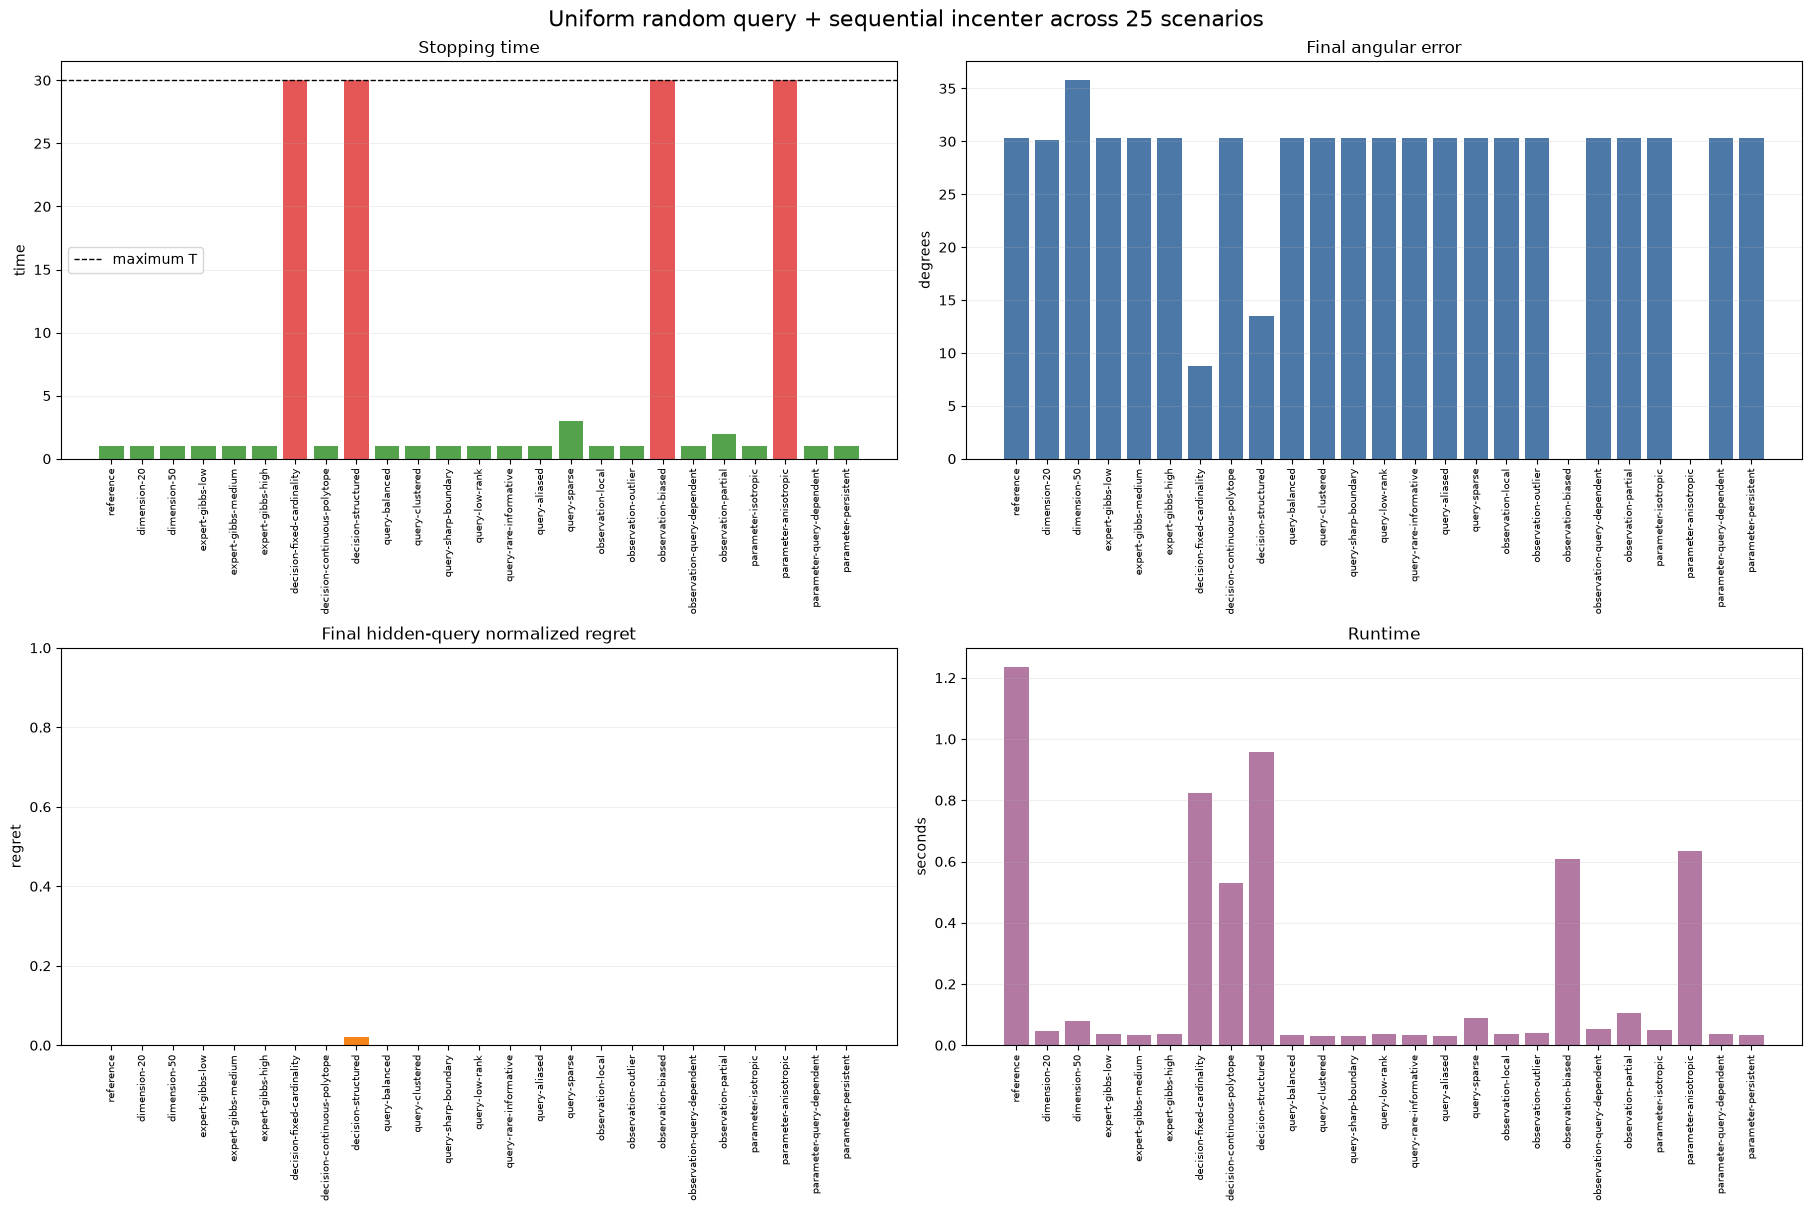

Green stopping-time bars reached zero regret; red bars reached the fixed horizon or stopped without zero regret.


In [6]:
plot_data = successful.reset_index(drop=True)
positions = np.arange(len(plot_data))
colors = np.where(plot_data['zero_regret_reached'], '#54A24B', '#E45756')
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

axes[0, 0].bar(positions, plot_data['stopping_time'], color=colors)
axes[0, 0].axhline(MAX_HORIZON, color='black', linestyle='--', linewidth=1, label='maximum T')
axes[0, 0].set(title='Stopping time', ylabel='time', xticks=positions)
axes[0, 0].legend()

axes[0, 1].bar(positions, plot_data['angular_error_deg'], color='#4C78A8')
axes[0, 1].set(title='Final angular error', ylabel='degrees', xticks=positions)

axes[1, 0].bar(positions, plot_data['normalized_regret'], color='#F58518')
axes[1, 0].set(title='Final hidden-query normalized regret', ylabel='regret', ylim=(0, 1), xticks=positions)

axes[1, 1].bar(positions, plot_data['runtime_seconds'], color='#B279A2')
axes[1, 1].set(title='Runtime', ylabel='seconds', xticks=positions)

for axis in axes.ravel():
    axis.set_xticklabels(plot_data['scenario'], rotation=90, fontsize=7)
    axis.grid(axis='y', alpha=0.2)
fig.suptitle('Uniform random query + sequential incenter across 25 scenarios', fontsize=16)
plt.show()
print('Green stopping-time bars reached zero regret; red bars reached the fixed horizon or stopped without zero regret.')

In [7]:
output_directory = Path('../outputs/active/curated-25-scenarios')
benchmark.save(output_directory)
print(f'Raw run files saved to: {output_directory.resolve()}')
print('All tables, summaries, progress, and plots are stored permanently in this executed notebook.')

Raw run files saved to: C:\Users\payam\Desktop\Inverse Optimization\outputs\active\curated-25-scenarios
All tables, summaries, progress, and plots are stored permanently in this executed notebook.
